In [47]:
import pandas as pd
import numpy as np   
import seaborn as sns
import matplotlib.pyplot as plt
                           


In [48]:
placement_data = {
    "cgpa": [
        3.95, 3.82, 3.76, 3.68, 3.60, 3.55, 3.48, 3.42, 3.38, 3.34,
        3.30, 3.28, 3.25, 3.20, 3.18, 3.15, 3.12, 3.10, 3.05, 3.00,
        2.98, 2.95, 2.92, 2.90, 2.88, 2.85, 2.82, 2.80, 2.78, 2.75,
        2.72, 2.70, 2.68, 2.65, 2.62, 2.60, 2.58, 2.55, 2.50, 2.48,
        2.45, 2.42, 2.40, 2.38, 2.35, 2.32, 2.30, 2.28, 2.25, 2.20
    ],

    "resume_score": [
        95, 88, 90, 78, 82, 75, 86, 72, 80, 69,
        74, 83, 68, 71, 85, 66, 70, 79, 64, 76,
        62, 73, 60, 69, 58, 72, 57, 65, 63, 59,
        67, 55, 61, 54, 66, 52, 56, 53, 60, 51,
        49, 58, 47, 55, 46, 50, 45, 48, 44, 42
    ],

    "placement": [
        1,1,1,1,1,1,1,1,1,0,
        1,1,0,1,1,0,0,1,0,1,
        0,1,0,0,0,1,0,0,0,0,
        0,0,0,0,0,0,0,0,0,0,
        0,0,0,0,0,0,0,0,0,0
    ]
}

In [49]:
df = pd.DataFrame(placement_data)
df.head()

,cgpa,resume_score,placement
0,3.95,95,1
1,3.82,88,1
2,3.76,90,1
3,3.68,78,1
4,3.60,82,1


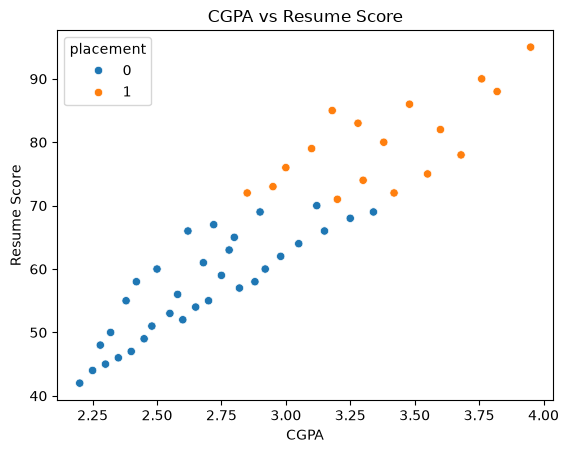

In [50]:
sns.scatterplot(
    data=df,
    x="cgpa",
    y="resume_score",
    hue="placement"
)

plt.xlabel("CGPA")
plt.ylabel("Resume Score")
plt.title("CGPA vs Resume Score")
plt.show()

In [51]:
X = df.drop(columns="placement")
y = df["placement"]
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [52]:
from sklearn.linear_model import Perceptron

p = Perceptron(max_iter=1000, tol=1e-3)
p.fit(X_scaled, y)

,"penalty penalty: {'l2','l1','elasticnet'}, default=NoneThe penalty (aka regularization term) to be used.",None
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term if regularization isused.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with `0 <= l1_ratio <= 1`.`l1_ratio=0` corresponds to L2 penalty, `l1_ratio=1` to L1.Only used if `penalty='elasticnet'`... versionadded:: 0.24",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, the iterations will stopwhen (loss > previous_loss - tol)... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.",0
,"eta0 eta0: float, default=1Constant by which the updates are multiplied.",1.0
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"random_state random_state: int, RandomState instance or None, default=0Used to shuffle the training data, when ``shuffle`` is set to``True``. Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",0


In [53]:
p.coef_

array([[-0.29436882,  4.7743671 ]])

In [54]:
print(p.coef_ ,)
print(p.intercept_)

[[-0.29436882  4.7743671 ]]
[-2.]


In [55]:
from mlxtend.plotting import plot_decision_regions

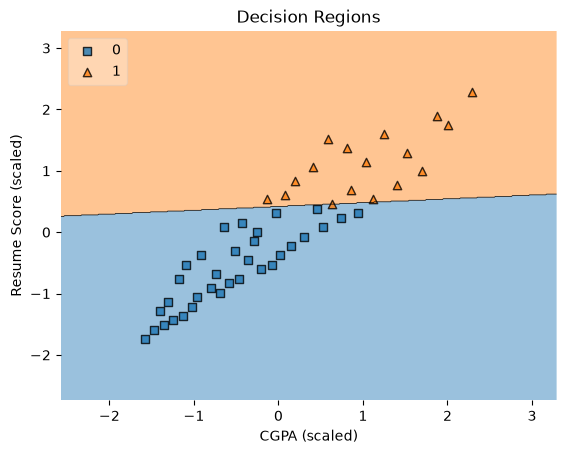

In [56]:


from mlxtend.plotting import plot_decision_regions
import matplotlib.pyplot as plt

plot_decision_regions(X_scaled, y.values, clf=p, legend=2)

plt.xlabel("CGPA (scaled)")
plt.ylabel("Resume Score (scaled)")
plt.title("Decision Regions")
plt.show()

In [58]:
import numpy as np

print(np.unique(p.predict(X_scaled), return_counts=True))

(array([0, 1]), array([33, 17]))
